Import statements

In [84]:
import random
import math
from typing import List
import matplotlib.pyplot as plt

Create VRP Instance

In [85]:
class VRPInstance:
    def __init__(self, depot, customers, item_weights, capacity):

        self.capacity = capacity
        self.item_weights = item_weights
        self.customers_list = customers
        self.depot = depot

        # coordinates
        self.nodes = {c["id"]: (c["x"], c["y"]) for c in customers}
        self.nodes[0] = (depot["x"], depot["y"])

        # compute total demand per customer
        self.demand = {}
        for c in customers:
            cid = c["id"]
            total = 0
            for item_id, units in c["orders"].items():
                total += units * item_weights[item_id]
            self.demand[cid] = total

        self.demand[0] = 0  # depot demand

        # distance matrix
        max_id = max(self.nodes.keys())
        self.dist = [[0] * (max_id + 1) for _ in range(max_id + 1)]

        for i in self.nodes:
            for j in self.nodes:
                self.dist[i][j] = math.dist(self.nodes[i], self.nodes[j])

    def distance(self, i, j):
        return self.dist[i][j]


Chromosome definition

In [86]:
class Chromosome:
    """
    Chromosome as a giant tour with depot markers:
        [0, 3, 2, 5, 0, 1, 4, 0]
    """

    def __init__(self, genes: List[int], instance: VRPInstance):
        self.genes = genes
        self.instance = instance
        self.cost = None
        self.fitness = None

    # -----------------------------------
    def decode_routes(self) -> List[List[int]]:
        """
        Convert the chromosome into a list of vehicle routes.
        """
        routes = []
        current = []

        for g in self.genes:
            if g == 0:
                if current:
                    routes.append([0] + current + [0])
                    current = []
            else:
                current.append(g)

        return routes

    # -----------------------------------
    def evaluate(self, penalty_factor: float = 1000.0, vehicle_count: int = 0) -> float:
        routes = self.decode_routes()
        total_dist = 0.0
        penalty = 0.0

        if vehicle_count > 0:
            route_count = len(routes)
            if route_count != vehicle_count:
                penalty += abs(route_count - vehicle_count) * 1e6

        for route in routes:
            load = sum(self.instance.demand[n] for n in route if n != 0)

            if load > self.instance.capacity:
                penalty += penalty_factor * (load - self.instance.capacity)

            for i in range(len(route) - 1):
                total_dist += self.instance.distance(route[i], route[i + 1])

        self.cost = total_dist + penalty
        self.fitness = 1 / (1 + self.cost)
        return self.fitness

    # -----------------------------------
    @staticmethod
    def create_random(instance: VRPInstance, vehicle_count: int = 0):
        customers = [c["id"] for c in instance.customers_list]
        random.shuffle(customers)

        if vehicle_count > 0:
            # split customers evenly into vehicle_count groups
            groups = [[] for _ in range(vehicle_count)]
            for i, c in enumerate(customers):
                groups[i % vehicle_count].append(c)

            genes = []
            for group in groups:
                genes.append(0)
                genes.extend(group)
            genes.append(0)

            return Chromosome(genes, instance)

        genes = [0]
        load = 0

        for c in customers:
            demand = instance.demand[c]
            if load + demand > instance.capacity:
                genes.append(0)
                load = 0
            genes.append(c)
            load += demand

        genes.append(0)
        return Chromosome(genes, instance)



Tournament Selection

In [70]:
def tournament_selection(population: List[Chromosome], k: int = 3) -> Chromosome:
    candidates = random.sample(population, k)
    return min(candidates, key=lambda c: c.cost)

Order Crossover

In [71]:
def order_crossover(p1: Chromosome, p2: Chromosome) -> List[int]:
    # extract customers only
    c1 = [g for g in p1.genes if g != 0]
    c2 = [g for g in p2.genes if g != 0]

    size = len(c1)
    a, b = sorted(random.sample(range(size), 2))

    child = [None] * size
    child[a:b] = c1[a:b]

    fill_values = [x for x in c2 if x not in child]
    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill_values[idx]
            idx += 1

    return child


Depot Reinsertion

In [72]:
def insert_depots(customer_list: List[int], instance: VRPInstance, vehicle_count: int = 0) -> List[int]:
    if vehicle_count > 0:
        groups = [[] for _ in range(vehicle_count)]
        for i, c in enumerate(customer_list):
            groups[i % vehicle_count].append(c)

        genes = []
        for group in groups:
            genes.append(0)
            genes.extend(group)
        genes.append(0)

        return genes

    genes = [0]
    load = 0

    for c in customer_list:
        demand = instance.demand[c]
        if load + demand > instance.capacity:
            genes.append(0)
            load = 0
        genes.append(c)
        load += demand

    genes.append(0)
    return genes



Mutation

In [73]:
def swap_mutation(customer_seq: List[int], rate: float = 0.1):
    if random.random() < rate:
        i, j = random.sample(range(len(customer_seq)), 2)
        customer_seq[i], customer_seq[j] = customer_seq[j], customer_seq[i]


Main Loop

In [76]:
def run_ga(instance: VRPInstance,
           population_size=60,
           generations=200,
           crossover_rate=0.9,
           mutation_rate=0.2,
           vehicle_count: int = 0):
    # Initialize population
    population = [Chromosome.create_random(instance, vehicle_count) for _ in range(population_size)]
    for ind in population:
        ind.evaluate(vehicle_count=vehicle_count)

    best = min(population, key=lambda c: c.cost)

    for gen in range(generations):
        new_pop = []

        while len(new_pop) < population_size:
            p1 = tournament_selection(population)
            p2 = tournament_selection(population)

            # Crossover
            if random.random() < crossover_rate:
                child_customers = order_crossover(p1, p2)
            else:
                child_customers = [g for g in p1.genes if g != 0]

            # Mutation
            swap_mutation(child_customers, mutation_rate)

            # Reinsert depots
            new_genes = insert_depots(child_customers, instance, vehicle_count)
            child = Chromosome(new_genes, instance)
            child.evaluate()

            new_pop.append(child)

        population = new_pop
        gen_best = min(population, key=lambda c: c.cost)

        if gen_best.cost < best.cost:
            best = gen_best

        if gen % 20 == 0:
            print(f"Generation {gen}, Best Cost = {best.cost:.2f}")

    return best


Plotter

In [77]:
def tournament_selection(population: List[Chromosome], k: int = 3) -> Chromosome:
    candidates = random.sample(population, k)
    return min(candidates, key=lambda c: c.cost)

## Test Case

In [90]:
# Define a demo instance
depot = {"id": 0, "x": 50, "y": 50}
# Item weights (kg)
item_weights = {
    1: 1.2, 2: 3.8, 3: 7.5, 4: 0.9, 5: 15.4,
    6: 12.1, 7: 4.3, 8: 19.7, 9: 8.6, 10: 2.5
}

# Customers with multi-item orders
customers = [
    {"id": 1, "x": 35, "y": 115, "orders": {3: 2, 1: 3}},  # C1
    {"id": 2, "x": 50, "y": 140, "orders": {2: 6}},  # C2
    {"id": 3, "x": 70, "y": 100, "orders": {7: 4, 5: 2}},  # C3
    {"id": 4, "x": 40, "y": 80, "orders": {3: 8}},  # C4
    {"id": 5, "x": 25, "y": 60, "orders": {6: 5, 9: 2}},  # C5
]

depot = {"id": 0, "x": 20, "y": 120}
capacity = 60

instance = VRPInstance(depot, customers, item_weights, capacity)

best = run_ga(instance,
              population_size=60,
              generations=200,
              crossover_rate=0.9,
              mutation_rate=0.2,
              vehicle_count=2)

print("Best Cost:", best.cost)
best_routes = best.decode_routes()
best_routes


Generation 0, Best Cost = 107364.60
Generation 20, Best Cost = 107364.60
Generation 40, Best Cost = 107364.60
Generation 60, Best Cost = 107364.60
Generation 80, Best Cost = 107364.60
Generation 100, Best Cost = 107364.60
Generation 120, Best Cost = 107364.60
Generation 140, Best Cost = 107364.60
Generation 160, Best Cost = 107364.60
Generation 180, Best Cost = 107364.60
Best Cost: 107364.59645857876


[[0, 1, 3, 2, 0], [0, 5, 4, 0]]

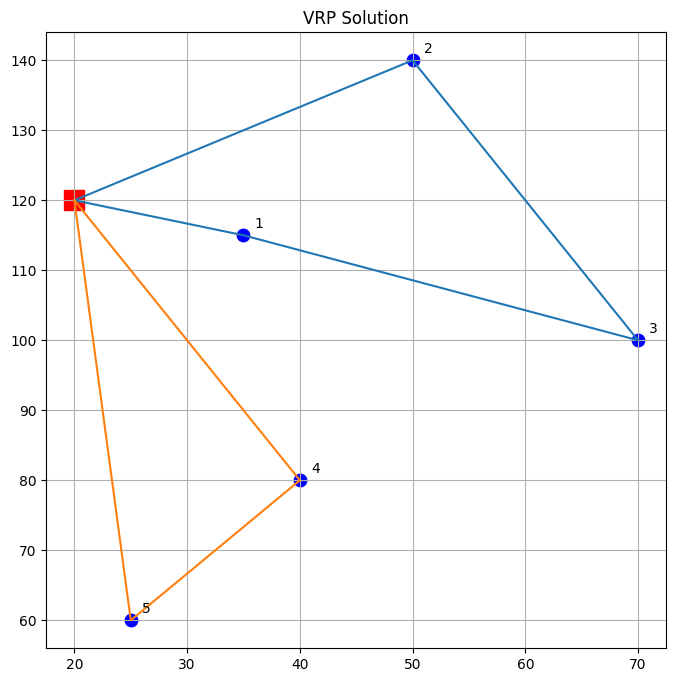

In [91]:
def plot_solution(chrom: Chromosome):
    routes = chrom.decode_routes()
    coords = chrom.instance.nodes

    plt.figure(figsize=(8, 8))

    # Plot depot
    dx, dy = coords[0]
    plt.scatter(dx, dy, c='red', s=200, marker='s')

    # Plot customers
    for i, (x, y) in coords.items():
        if i != 0:
            plt.scatter(x, y, c='blue', s=80)
            plt.text(x + 1, y + 1, str(i))

    # Draw routes
    for route in routes:
        xs = [coords[n][0] for n in route]
        ys = [coords[n][1] for n in route]
        plt.plot(xs, ys)

    plt.title("VRP Solution")
    plt.grid(True)
    plt.show()


plot_solution(best)


Experiment with dataset